# Causal Graph Probing (CGP): demo and comparison with mixture-EM

This notebook has two parts:

1. Demonstration of CGP applied to synthetic datasets
2. **CGP vs. mixture-EM** — A wider comparison between CGP and Expectation Maximization (a standard algorithm that can be used for DAG recovery) on linear and nonlinear data.

| method | what it is | how it searches |
|---|---|---|
| **CGP** | cluster → estimate each cluster's affinity toward each candidate DAG → partition → rank candidate DAG pairs by combined AR ("Final AR"). Nonlinear-AR adds polynomial features. | ranks all 55 pairs of the 11 three-node equivalence classes |
| **Mixture-of-SEMs EM** | baseline: a Gaussian mixture with per-component covariance constrained by a DAG | ranks all 55 pairs using BIC |


In [1]:
import sys, os
from pathlib import Path

# Resolve the repo root so the notebook works whether opened from the repo root
# or from notebooks/, and add it to the path for imports and data files.
REPO = Path.cwd()
if REPO.name == "notebooks":
    REPO = REPO.parent
os.chdir(REPO)
sys.path.insert(0, str(REPO))

from itertools import permutations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from cgp.datagen import sample_k_mixture
from cgp.probing import (
    THREE_NODE_EQUIVALENCE_CLASSES as CANDIDATES,
    affinitize_clusters, generate_kmeans_clusters, optimize_graphs, trichotomize_data,
)
from cgp.viz import plot_clusters_corner
from scripts.compare_cgp_em import cgp_recover, em_recover

def graph(i):
    return sorted(CANDIDATES[i])

print("candidate graphs 0..10:")
for i, g in enumerate(CANDIDATES):
    print(f"  {i:2d}: {sorted(g)}")
%matplotlib inline

candidate graphs 0..10:
   0: []
   1: [(0, 1)]
   2: [(1, 2)]
   3: [(0, 2)]
   4: [(0, 1), (0, 2)]
   5: [(0, 2), (2, 1)]
   6: [(1, 0), (1, 2)]
   7: [(0, 2), (1, 2)]
   8: [(1, 0), (2, 0)]
   9: [(0, 1), (2, 1)]
  10: [(0, 1), (0, 2), (1, 2)]


---
# Part 1 — CGP Demonstration

## Implementation on a hard (distance-1) pair

`data/synthetic/hard_pair/` is a difficult case: two DAGs that differ by
a single edge. One is a complete 3-node graph (`CANDIDATES[10]`) vs. the same graph
with one edge removed (`CANDIDATES[7]`).


true DAG 1 (complete): [(0, 1), (0, 2), (1, 2)]  true DAG 2 (one edge removed): [(0, 2), (1, 2)]


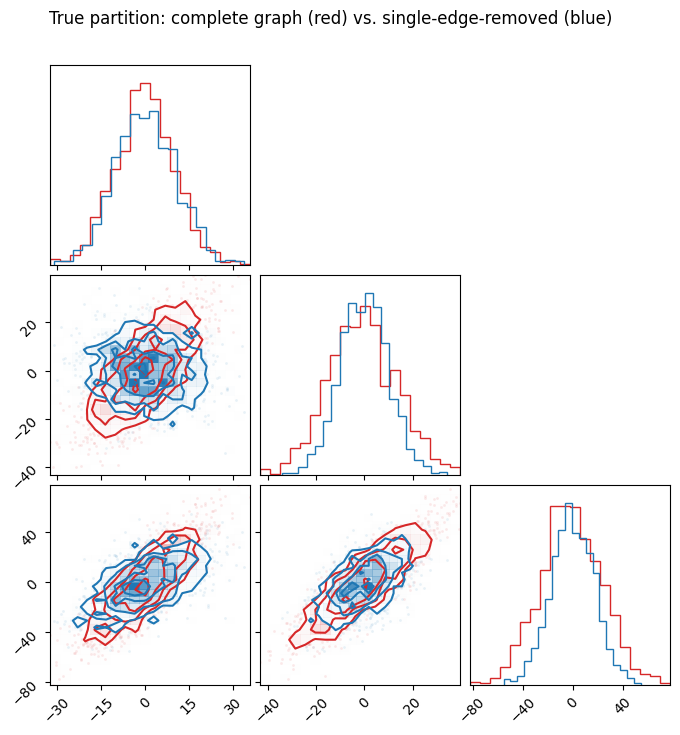

In [2]:
merged = np.loadtxt("data/synthetic/hard_pair/merged.dat", skiprows=1)
true_sub1 = np.loadtxt("data/synthetic/hard_pair/true_subset1.dat", skiprows=1)
true_sub2 = np.loadtxt("data/synthetic/hard_pair/true_subset2.dat", skiprows=1)
true_dag1, true_dag2 = CANDIDATES[10], CANDIDATES[7]
print("true DAG 1 (complete):", graph(10), " true DAG 2 (one edge removed):", graph(7))

fig = plot_clusters_corner([true_sub1, true_sub2], colors=["tab:red", "tab:blue"])
fig.suptitle("True partition: complete graph (red) vs. single-edge-removed (blue)", y=1.02)
plt.show()

## CGP Search Over Graph Space

`optimize_graphs` runs the full CGP pipeline — k-means clustering, per-cluster
affinity toward each candidate DAG, a threshold
into a partition, and the combined "Final AR" (FAR) of that partition — over each of the 55 candidate pairs, and returns the lowest-FAR pair. 

This method is efficient
due to the covariance-based AR reformulation.


CGP best pair: ([(0, 2), (1, 2)], [(0, 2), (2, 1)])  (FAR=193.57)
True pair (complete vs. single-edge-removed) ranked 2/55, FAR=194.96


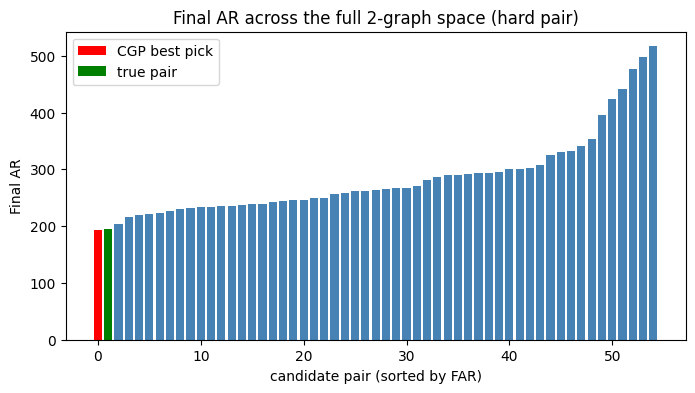

In [3]:
rng = np.random.default_rng(1)
fars, best_pair = optimize_graphs(merged, nclusters=40, subset_size=1000, nsubsets=2000, ntrials=40, rng=rng)

flat = sorted((fars[i, j], i, j) for i in range(len(CANDIDATES)) for j in range(i))
true_rank = next(k for k, (_, i, j) in enumerate(flat, 1) if {i, j} == {10, 7})
print(f"CGP best pair: {best_pair}  (FAR={flat[0][0]:.2f})")
print(f"True pair (complete vs. single-edge-removed) ranked {true_rank}/{len(flat)}, FAR={fars[10,7]:.2f}")

values = [f for f, i, j in flat]
true_idx = next(k for k, (_, i, j) in enumerate(flat) if {i, j} == {10, 7})
plt.figure(figsize=(8, 4))
plt.bar(range(len(values)), values, color="steelblue")
plt.bar(0, values[0], color="red", label="CGP best pick")
plt.bar(true_idx, values[true_idx], color="green", label="true pair")
plt.xlabel("candidate pair (sorted by FAR)"); plt.ylabel("Final AR")
plt.title("Final AR across the full 2-graph space (hard pair)")
plt.legend(); plt.show()

## Visualization of Recovered Partition

Given the winning pair, each cluster is assigned to the DAG of higher affinity
(with a small threshold to account for points that are practically indistinguishable). 


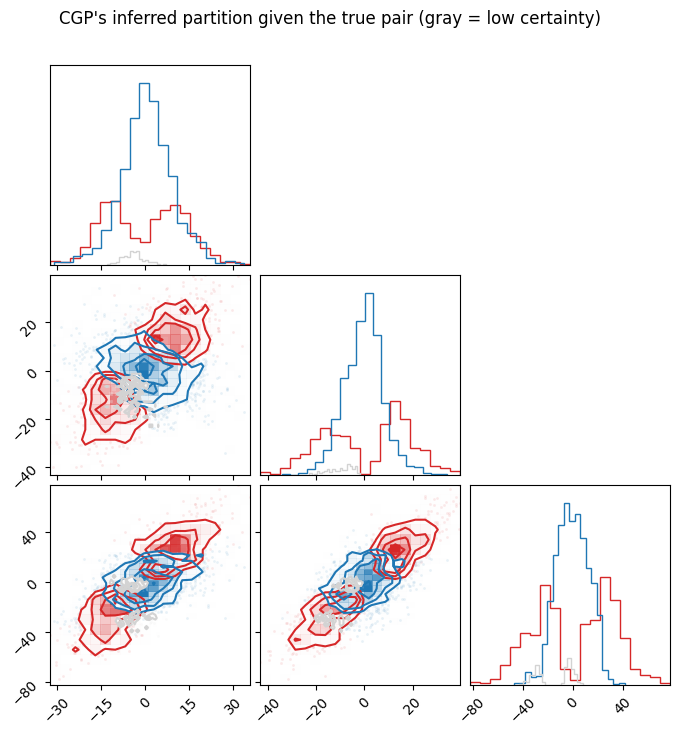

assigned 988 points to DAG 1, 1834 to DAG 2, 178 neutral (of 3000 total)


In [4]:
clusters = generate_kmeans_clusters(merged, nclusters=40)
affinities = affinitize_clusters(clusters, true_dag1, true_dag2, subset_size=1000, nsubsets=2000)
threshold = min(abs(affinities.min()), abs(affinities.max())) / 10
neutral_pts, dag1_pts, dag2_pts = trichotomize_data(clusters, affinities, threshold)

fig = plot_clusters_corner([dag1_pts, dag2_pts, neutral_pts],
                           colors=["tab:red", "tab:blue", "lightgray"])
fig.suptitle("CGP's inferred partition given the true pair (gray = low certainty)", y=1.02)
plt.show()
print(f"assigned {dag1_pts.shape[0]} points to DAG 1, {dag2_pts.shape[0]} to DAG 2, "
      f"{neutral_pts.shape[0]} neutral (of {merged.shape[0]} total)")

### Same partition, in PCA space

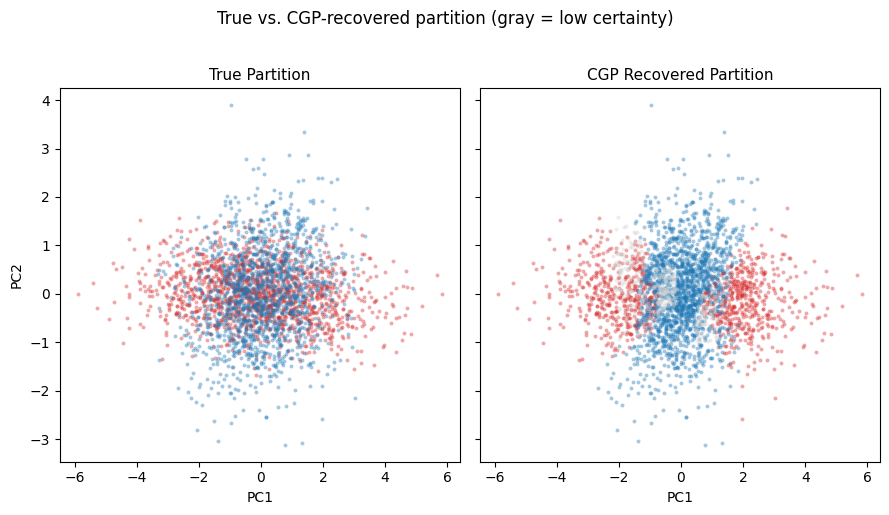

301 points (10%) assigned low-certainty (gray)


In [5]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# generate_kmeans_clusters (above) only returns grouped point arrays, discarding
# the row -> cluster mapping needed to color a per-point PCA scatter -- so redo the
# clustering here keeping that mapping (clab).
NCLUSTERS = 40
km = KMeans(n_clusters=NCLUSTERS, n_init=10, random_state=0).fit(merged)
clab = km.labels_
clusters_pca = [merged[clab == i] for i in range(NCLUSTERS)]
affinities_pca = affinitize_clusters(clusters_pca, true_dag1, true_dag2, subset_size=1000, nsubsets=2000)
threshold_pca = min(abs(affinities_pca.min()), abs(affinities_pca.max())) / 10

# per-cluster bucket (0=dag1/red, 1=dag2/blue, 2=neutral/low-certainty/gray),
# broadcast from cluster-level to point-level via clab -- same rule as trichotomize_data
cluster_bucket = np.where(np.abs(affinities_pca) < threshold_pca, 2,
                          np.where(affinities_pca < 0, 0, 1))
recovered_labels = cluster_bucket[clab]

true_labels = np.array([0] * true_sub1.shape[0] + [1] * true_sub2.shape[0])
assert len(true_labels) == merged.shape[0]

xy = PCA(n_components=2).fit_transform((merged - merged.mean(0)) / merged.std(0))
colors = {0: "tab:red", 1: "tab:blue", 2: "lightgray"}

fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharex=True, sharey=True)
for ax, (title, lbl, buckets) in zip(axes, [("True Partition", true_labels, (0, 1)),
                                            ("CGP Recovered Partition", recovered_labels, (0, 1, 2))]):
    for b in buckets:
        m = lbl == b
        ax.scatter(xy[m, 0], xy[m, 1], s=8, c=colors[b], alpha=0.4, linewidths=0)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("PC1")
axes[0].set_ylabel("PC2")
fig.suptitle("True vs. CGP-recovered partition (gray = low certainty)", y=1.02)
plt.tight_layout()
plt.show()

n_neutral = int((recovered_labels == 2).sum())
print(f"{n_neutral} points ({n_neutral / merged.shape[0]:.0%}) assigned low-certainty (gray)")

---
# Part 2 — CGP vs. mixture-EM comparison

We compare both methods across linear and nonlinear data.

In the nonlinear case (i.e., containing edges `X_j = f_j(parents) + Gaussian noise`, with `f_j`
nonlinear) the joint distribution is non-Gaussian, which
violates EM's core assumption.

We show that CGP is thus more robust in this nonlinear case.


In [6]:
def demo(true_pair, quad_coef_range, label, seed=0):
    merged, _ = sample_k_mixture([CANDIDATES[true_pair[0]], CANDIDATES[true_pair[1]]],
                                 num_vars=3, n_each=800, mechanism="quadratic",
                                 rng=np.random.default_rng(seed), quad_coef_range=quad_coef_range)
    tl = np.array([0]*800 + [1]*800)
    cgp = cgp_recover(merged, true_pair, tl, degree=2, rng=np.random.default_rng(seed))
    em  = em_recover(merged, true_pair, tl, rng=np.random.default_rng(seed))
    print(f"=== {label}: true DAGs {graph(true_pair[0])} , {graph(true_pair[1])} ===")
    print(f"  CGP (nl-AR): true-pair rank {cgp['rank']}/55, SHD-to-truth {cgp['shd']}, partition {cgp['partition_acc']:.2f}")
    print(f"  EM         : true-pair rank {em['rank']}/55, SHD-to-truth {em['shd']}, partition {em['partition_acc']:.2f}")
    return cgp, em

_ = demo((1, 7), (0.0, 0.0), "LINEAR, well-separated  (EM regime)")

=== LINEAR, well-separated  (EM regime): true DAGs [(0, 1)] , [(0, 2), (1, 2)] ===
  CGP (nl-AR): true-pair rank 2/55, SHD-to-truth 1, partition 0.75
  EM         : true-pair rank 1/55, SHD-to-truth 0, partition 0.81


In [7]:
_ = demo((1, 7), (2.0, 3.5), "STRONG nonlinear, well-separated  (CGP regime; same pair as above)")

=== STRONG nonlinear, well-separated  (CGP regime; same pair as above): true DAGs [(0, 1)] , [(0, 2), (1, 2)] ===
  CGP (nl-AR): true-pair rank 2/55, SHD-to-truth 1, partition 0.63
  EM         : true-pair rank 53/55, SHD-to-truth 3, partition 0.51


In [8]:
_ = demo((7, 10), (2.0, 3.5), "STRONG nonlinear, NESTED dist-1  (CGP regime)")

=== STRONG nonlinear, NESTED dist-1  (CGP regime): true DAGs [(0, 2), (1, 2)] , [(0, 1), (0, 2), (1, 2)] ===
  CGP (nl-AR): true-pair rank 1/55, SHD-to-truth 0, partition 0.59
  EM         : true-pair rank 12/55, SHD-to-truth 3, partition 0.55


## Examples of recovered graphs in linear and nonlinear cases


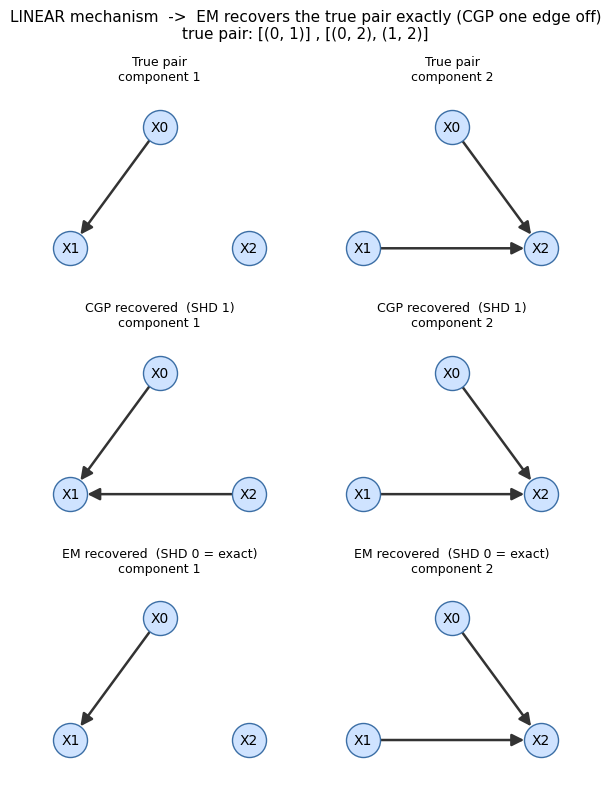

In [9]:
POS = {0: (0.0, 1.0), 1: (-0.9, -0.6), 2: (0.9, -0.6)}

def draw_dag(ax, edges, title):
    G = nx.DiGraph(); G.add_nodes_from([0, 1, 2]); G.add_edges_from([tuple(e) for e in edges])
    nx.draw_networkx_nodes(G, POS, ax=ax, node_size=600, node_color="#cfe3ff", edgecolors="#3b6ea5")
    nx.draw_networkx_labels(G, POS, ax=ax, labels={i: f"X{i}" for i in range(3)}, font_size=10)
    nx.draw_networkx_edges(G, POS, ax=ax, arrows=True, arrowsize=18, node_size=600,
                           width=1.8, edge_color="#333")
    ax.set_title(title, fontsize=9); ax.set_axis_off()
    ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.1, 1.5)

def _align(recovered_idx, true_pair):
    """Order the recovered pair's two edge lists to best match the true pair."""
    tv = [set(map(tuple, CANDIDATES[true_pair[0]])), set(map(tuple, CANDIDATES[true_pair[1]]))]
    rv = [CANDIDATES[recovered_idx[0]], CANDIDATES[recovered_idx[1]]]
    best = min(permutations(range(2)),
               key=lambda p: sum(len(set(map(tuple, rv[p[k]])) ^ tv[k]) for k in range(2)))
    return [rv[best[0]], rv[best[1]]]

def show_recovered(true_pair, quad_coef_range, regime, seed=0):
    merged, _ = sample_k_mixture([CANDIDATES[true_pair[0]], CANDIDATES[true_pair[1]]],
                                 num_vars=3, n_each=800, mechanism="quadratic",
                                 rng=np.random.default_rng(seed), quad_coef_range=quad_coef_range)
    tl = np.array([0]*800 + [1]*800)
    cgp = cgp_recover(merged, true_pair, tl, degree=2, rng=np.random.default_rng(seed))
    em  = em_recover(merged, true_pair, tl, rng=np.random.default_rng(seed))
    rows = [("True pair", [CANDIDATES[true_pair[0]], CANDIDATES[true_pair[1]]]),
            (f"CGP recovered  (SHD {cgp['shd']}{' = exact' if cgp['shd']==0 else ''})", _align(cgp["top1_pair"], true_pair)),
            (f"EM recovered  (SHD {em['shd']}{' = exact' if em['shd']==0 else ''})", _align(em["top1_pair"], true_pair))]
    fig, axes = plt.subplots(3, 2, figsize=(6, 8))
    for r, (label, pair) in enumerate(rows):
        for c in range(2):
            draw_dag(axes[r, c], pair[c], f"{label}\ncomponent {c+1}")
    fig.suptitle(f"{regime}\ntrue pair: {graph(true_pair[0])} , {graph(true_pair[1])}", fontsize=11)
    plt.tight_layout(); plt.show()

show_recovered((1, 7), (0.0, 0.0), "LINEAR mechanism  ->  EM recovers the true pair exactly (CGP one edge off)")

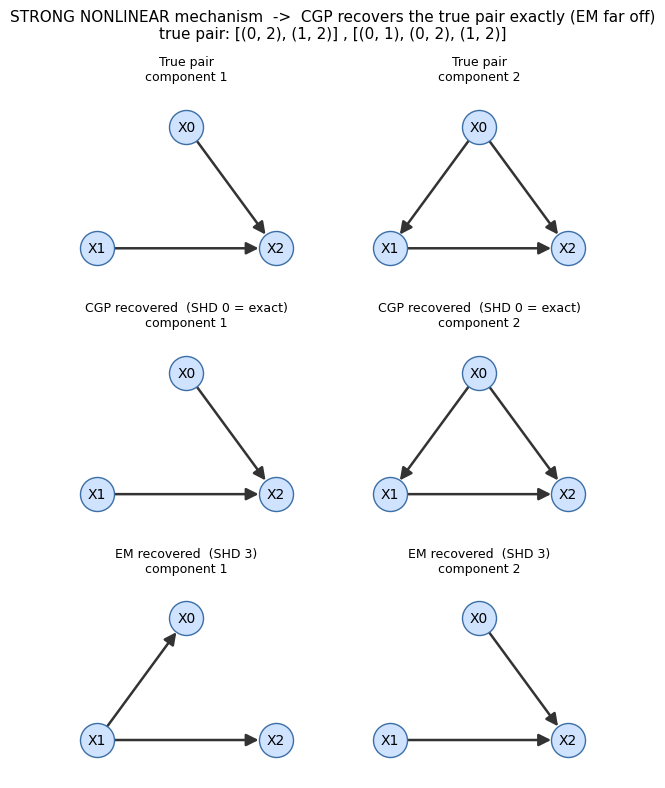

In [10]:
show_recovered((7, 10), (2.0, 3.5), "STRONG NONLINEAR mechanism  ->  CGP recovers the true pair exactly (EM far off)")

## 2.3 Full sweep

Precomputed over 4 pairs × 3 nonlinearity levels × 5 seeds
(`results/cgp_vs_em_comparison.csv`, reproducible via
`python scripts/compare_cgp_em.py`).

rank = ranking of true pair returned by algorithm, shd = structural distance of pair (graph recovery accuracy),
pacc = partition accuracy

In [11]:
df = pd.read_csv("results/cgp_vs_em_comparison.csv")
order = {"linear": 0, "moderate": 1, "strong": 2}
summary = (df.groupby(["pair", "level"])[["cgp_rank","cgp_shd","cgp_pacc","em_rank","em_shd","em_pacc"]]
             .mean().round(2).reset_index())
summary["_o"] = summary["level"].map(order)
summary = summary.sort_values(["pair", "_o"]).drop(columns="_o").set_index(["pair", "level"])
summary

cgp_rank  cgp_shd  cgp_pacc  em_rank  em_shd  \
pair                 level                                                    
(0,10) empty-vs-full linear         3.8      1.4      0.73     1.20     0.2   
                     moderate      10.6      2.0      0.64    22.40     3.0   
                     strong        10.0      2.0      0.64    41.50     3.5   
(1,7) separated      linear         1.6      0.6      0.73     1.40     0.2   
                     moderate       2.4      1.2      0.65    35.60     2.2   
                     strong         3.8      2.0      0.65    47.20     2.6   
(6,9) separated      linear         1.0      0.0      0.76     3.40     0.6   
                     moderate      13.8      3.2      0.67    35.80     4.0   
                     strong        21.2      4.2      0.59    47.60     4.6   
(7,10) nested dist-1 linear        15.6      2.2      0.74     1.60     1.2   
                     moderate       1.4      0.6      0.57    21.60     3.8   
                     strong         1.0      0.0      0.58     7.75     3.0   

                               em_pacc  
pair                 level              
(0,10) empty-vs-full linear       0.79  
                     moderate     0.57  
                     strong       0.55  
(1,7) separated      linear       0.77  
                     moderate     0.56  
                     strong       0.54  
(6,9) separated      linear       0.85  
                     moderate     0.56  
                     strong       0.55  
(7,10) nested dist-1 linear       0.84  
                     moderate     0.54  
                     strong       0.55

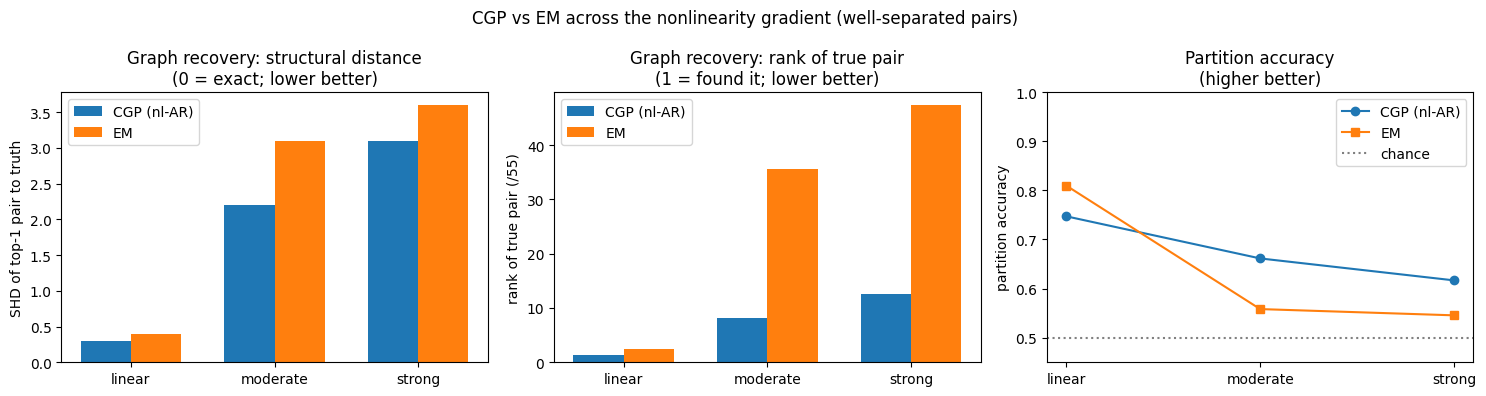

In [12]:
sep = df[df["pair"].str.contains("separated")]
levels = ["linear", "moderate", "strong"]
g = sep.groupby("level")[["cgp_rank","cgp_shd","cgp_pacc","em_rank","em_shd","em_pacc"]].mean().reindex(levels)
x = np.arange(len(levels)); w = 0.35

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].bar(x-w/2, g["cgp_shd"], w, label="CGP (nl-AR)"); ax[0].bar(x+w/2, g["em_shd"], w, label="EM")
ax[0].set_xticks(x); ax[0].set_xticklabels(levels); ax[0].set_ylabel("SHD of top-1 pair to truth")
ax[0].set_title("Graph recovery: structural distance\n(0 = exact; lower better)"); ax[0].legend()
ax[1].bar(x-w/2, g["cgp_rank"], w, label="CGP (nl-AR)"); ax[1].bar(x+w/2, g["em_rank"], w, label="EM")
ax[1].set_xticks(x); ax[1].set_xticklabels(levels); ax[1].set_ylabel("rank of true pair (/55)")
ax[1].set_title("Graph recovery: rank of true pair\n(1 = found it; lower better)"); ax[1].legend()
ax[2].plot(levels, g["cgp_pacc"], "o-", label="CGP (nl-AR)"); ax[2].plot(levels, g["em_pacc"], "s-", label="EM")
ax[2].axhline(0.5, ls=":", c="gray", label="chance")
ax[2].set_ylabel("partition accuracy"); ax[2].set_ylim(0.45, 1.0)
ax[2].set_title("Partition accuracy\n(higher better)"); ax[2].legend()
plt.suptitle("CGP vs EM across the nonlinearity gradient (well-separated pairs)")
plt.tight_layout(); plt.show()

In [13]:
for lname in ["linear", "moderate", "strong"]:
    d = df[df["level"] == lname]
    print(f"{lname:9s}  top-1 recovery:  CGP {np.mean(d.cgp_rank==1):.0%}   EM {np.mean(d.em_rank==1):.0%}"
          f"   |  mean rank: CGP {d.cgp_rank.mean():.1f}  EM {d.em_rank.mean():.1f}")

linear     top-1 recovery:  CGP 45%   EM 75%   |  mean rank: CGP 5.5  EM 1.9
moderate   top-1 recovery:  CGP 25%   EM 5%   |  mean rank: CGP 7.0  EM 28.9
strong     top-1 recovery:  CGP 25%   EM 0%   |  mean rank: CGP 9.0  EM 37.3


## Example of recovered point partition

Each
dataset is projected to 2D (first two principal components of the standardised
data)

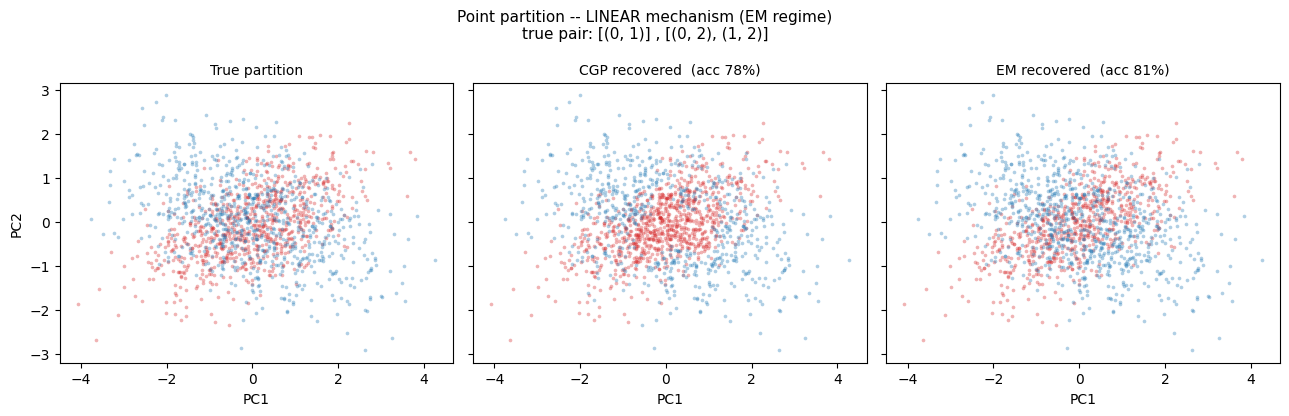

In [14]:
from sklearn.decomposition import PCA

def show_partitions(true_pair, quad_coef_range, regime, seed=0, nclusters=25):
    merged, _ = sample_k_mixture([CANDIDATES[true_pair[0]], CANDIDATES[true_pair[1]]],
                                 num_vars=3, n_each=800, mechanism="quadratic",
                                 rng=np.random.default_rng(seed), quad_coef_range=quad_coef_range)
    tl = np.array([0] * 800 + [1] * 800)
    cgp = cgp_recover(merged, true_pair, tl, degree=2, rng=np.random.default_rng(seed),
                      params=dict(nclusters=nclusters, subset_size=300, nsubsets=200))
    em  = em_recover(merged, true_pair, tl, rng=np.random.default_rng(seed))

    # shared 2D view: first two PCs of the standardised data, so both components
    # (which can differ hugely in scale) are visible and the panels are comparable
    Z = (merged - merged.mean(0)) / merged.std(0)
    xy = PCA(n_components=2).fit_transform(Z)

    def align(lbl):  # flip labels so colour 0 lines up with true component 0
        return lbl if np.mean(lbl == tl) >= 0.5 else 1 - lbl

    panels = [("True partition", tl),
              (f"CGP recovered  (acc {cgp['partition_acc']:.0%})", align(cgp["labels"])),
              (f"EM recovered  (acc {em['partition_acc']:.0%})", align(em["labels"]))]
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharex=True, sharey=True)
    for ax, (title, lbl) in zip(axes, panels):
        for c, color in [(0, "tab:red"), (1, "tab:blue")]:
            m = lbl == c
            ax.scatter(xy[m, 0], xy[m, 1], s=7, c=color, alpha=0.35, linewidths=0)
        ax.set_title(title, fontsize=10); ax.set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    fig.suptitle(f"Point partition -- {regime}\n"
                 f"true pair: {graph(true_pair[0])} , {graph(true_pair[1])}", fontsize=11)
    plt.tight_layout(); plt.show()

show_partitions((1, 7), (0.0, 0.0), "LINEAR mechanism (EM regime)")

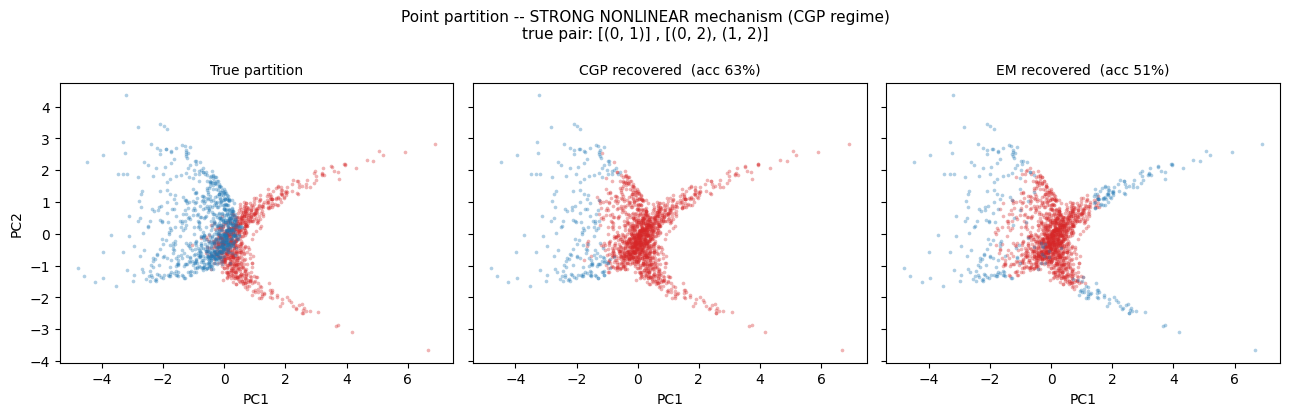

In [15]:
show_partitions((1, 7), (2.0, 3.5), "STRONG NONLINEAR mechanism (CGP regime)", nclusters=50)

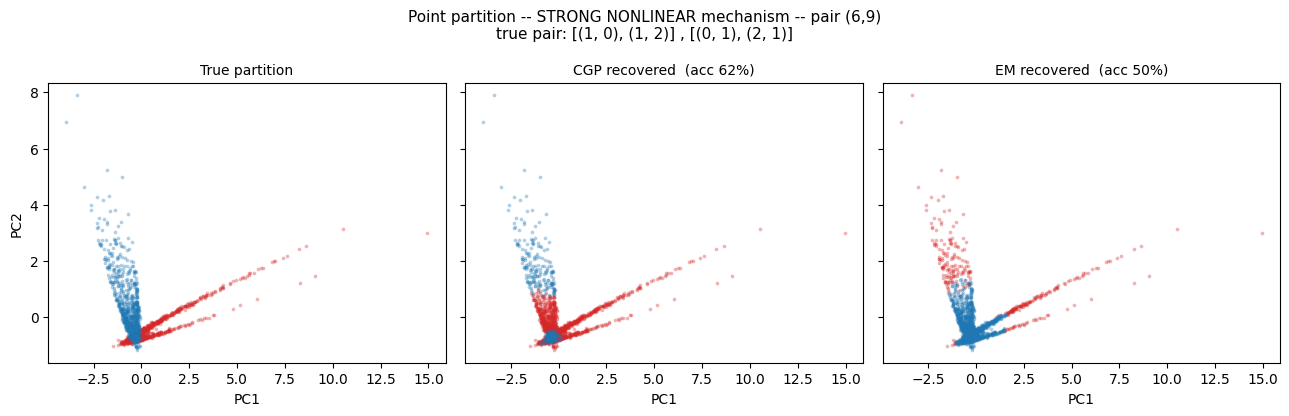

In [16]:
show_partitions((6, 9), (2.0, 3.5), "STRONG NONLINEAR mechanism -- pair (6,9)")

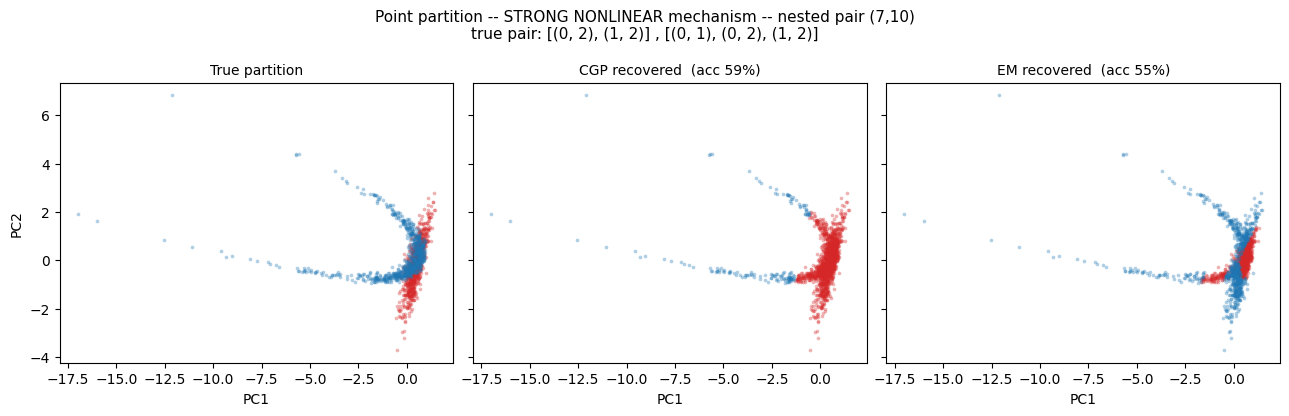

In [17]:
show_partitions((7, 10), (2.0, 3.5), "STRONG NONLINEAR mechanism -- nested pair (7,10)", nclusters=50)

## Prototype: CGP on >3-dimensional data and >2 graphs

Everything above uses 3-node synthetic mixtures. Here we run the prototype for
CGP on >3 nodes and with a mixture of 3 graphs. The dataset used is a real 7-feature dataset:
1460 galaxies from a Galacticus semi-analytic simulation (`basicMass`,
`diskMassStellar`, `spheroidMassStellar`, `diskMassGas`, `spheroidMassGas`,
`hotHaloMass`, `blackHoleMass`). 

Pipeline: standardise the 7 features, use greedy BIC discovery
(`cgp/discovery.py`) to generate candidate 7-node DAGs from data bootstraps
(replacing the hand-enumerated 3-node list), then run the K-way CGP partition
(cluster -> per-candidate affinity swings -> K-way assignment -> Final AR). 

Note that this cell is for illustrative purposes; further tests must be conducted
on how to properly extend CGP to >= 4 dimensions.

In [19]:
from itertools import combinations
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from cgp.discovery import candidate_pool
from cgp.probing import affinity_table
from cgp.scoring import averaged_residuals

GAL_PATH = "data/galacticus/galacticus_table.dat"
gal_cols = open(GAL_PATH).readline().split()
gal = np.loadtxt(GAL_PATH, skiprows=1)
Zg = (gal - gal.mean(0)) / gal.std(0)            # standardise the 7 features
print(f"Galacticus: {gal.shape[0]} galaxies x {gal.shape[1]} features")
print("  ", gal_cols)

# discover candidate 7-node DAGs from data bootstraps (greedy BIC hill-climb)
gal_pool = candidate_pool(Zg, n_bootstraps=30, bootstrap_frac=0.6, degree=1, rng=np.random.default_rng(0))
gal_candidates = [edges for edges, count in gal_pool]
print(f"{len(gal_candidates)} candidate DAGs discovered from bootstraps")

GAL_COLORS = ["tab:red", "tab:blue", "tab:green", "tab:orange"]
GAL_SHORT = ["Mbasic", "diskM*", "sphM*", "diskGas", "sphGas", "hotHalo", "BH"]  # * = stellar

def cgp_kway_labels(data, candidates, K, nclusters=25, subset_size=300, nsubsets=200, seed=0):
    """K-way CGP: cluster, score each cluster's affinity toward each candidate DAG,
    assign clusters K-way (per-candidate-centred swings), keep the K-tuple with the
    lowest Final AR. Returns per-point component labels."""
    rng = np.random.default_rng(seed)
    clab = KMeans(n_clusters=nclusters, n_init=10, random_state=seed).fit(data).labels_
    clusters = [data[clab == i] for i in range(nclusters)]
    table = affinity_table(clusters, candidates, subset_size, nsubsets, rng)
    tc = table - table.mean(0, keepdims=True)
    best = None
    for combo in combinations(range(len(candidates)), K):
        assign = np.argmin(tc[:, list(combo)], axis=1)
        if len(np.unique(assign)) < K:            # a component got no clusters -> skip
            continue
        far = sum(averaged_residuals(candidates[combo[k]],
                    data[np.isin(clab, [c for c in range(nclusters) if assign[c] == k])])
                  for k in range(K))
        if best is None or far < best[0]:
            best = (far, combo, assign.copy())
    far, combo, assign = best
    return assign[clab], combo, far

def show_galacticus(K, seed=0):
    labels, combo, far = cgp_kway_labels(Zg, gal_candidates, K, seed=seed)
    sizes = [int((labels == k).sum()) for k in range(K)]
    print(f"K={K}: component sizes {sizes}, Final AR {far:.3f}")

    xy = PCA(n_components=2).fit_transform(Zg)
    plt.figure(figsize=(5, 4))
    for k in range(K):
        m = labels == k
        plt.scatter(xy[m, 0], xy[m, 1], s=8, c=GAL_COLORS[k], alpha=0.4, label=f"comp {k} (n={sizes[k]})")
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(fontsize=8)
    plt.title(f"Galacticus -- CGP {K}-way partition (PCA view)")
    plt.tight_layout(); plt.show()

    d = Zg.shape[1]
    fig, axes = plt.subplots(d, d, figsize=(11, 11))
    for r in range(d):
        for c in range(d):
            ax = axes[r, c]
            if r == c:
                ax.text(0.5, 0.5, GAL_SHORT[r], ha="center", va="center", fontsize=9, transform=ax.transAxes)
                ax.set_xticks([]); ax.set_yticks([])
            elif r > c:
                for k in range(K):
                    m = labels == k
                    ax.scatter(Zg[m, c], Zg[m, r], s=3, c=GAL_COLORS[k], alpha=0.3, linewidths=0)
                ax.set_xticks([]); ax.set_yticks([])
            else:
                ax.axis("off")
    fig.suptitle(f"Galacticus -- CGP {K}-way partition (pairwise view of 7 features)", y=0.92)
    plt.tight_layout(); plt.show()

Galacticus: 1460 galaxies x 7 features
   ['basicMass', 'diskMassStellar', 'spheroidMassStellar', 'diskMassGas', 'spheroidMassGas', 'hotHaloMass', 'blackHoleMass']


30 candidate DAGs discovered from bootstraps


K=2: component sizes [167, 1293], Final AR 0.816


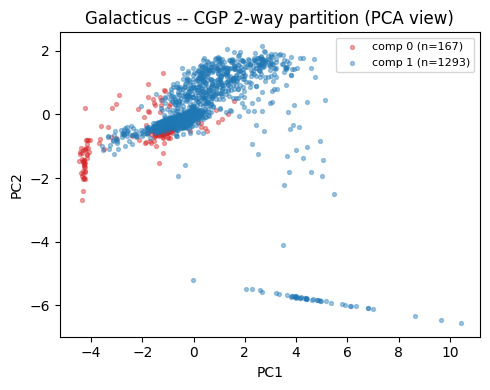

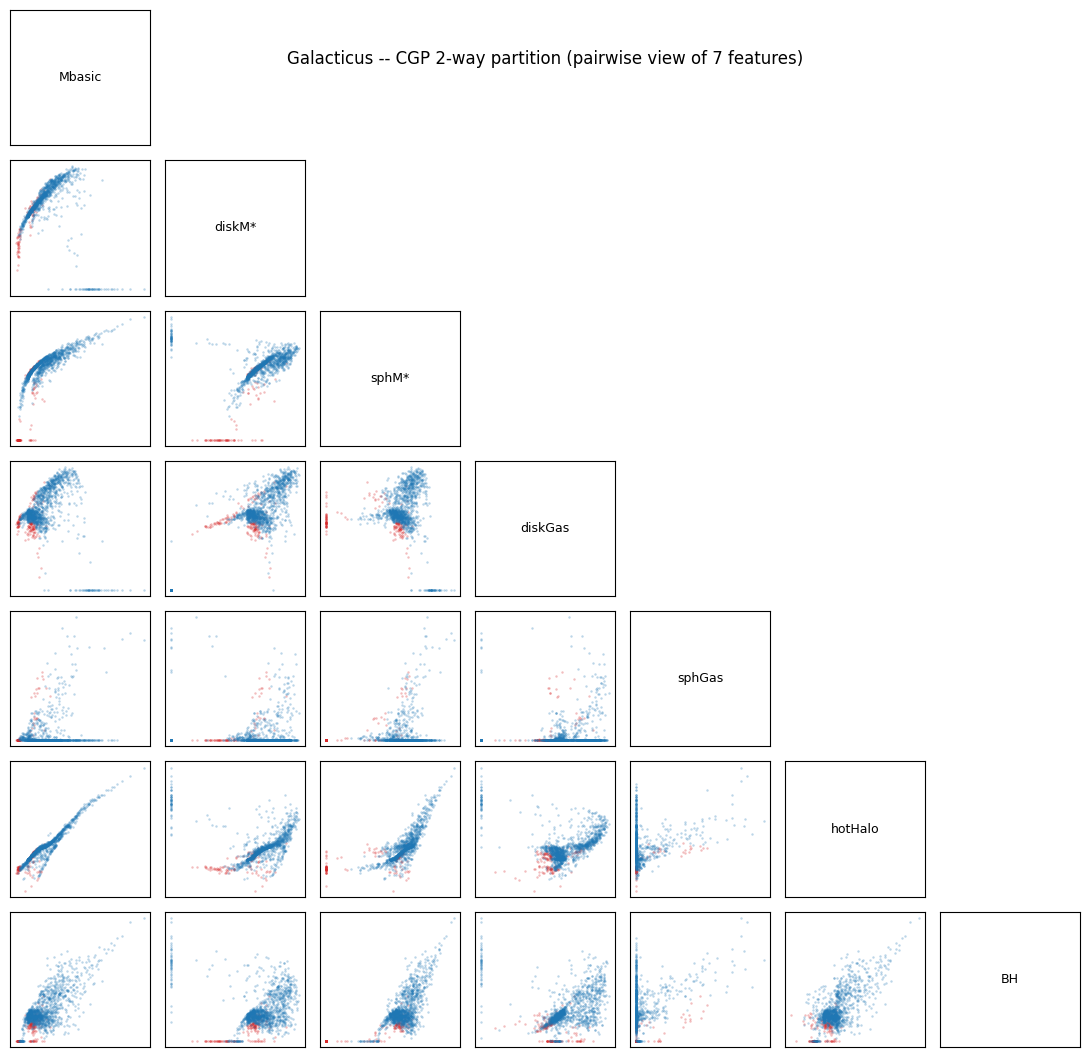

In [20]:
show_galacticus(2)

K=3: component sizes [517, 904, 39], Final AR 0.835


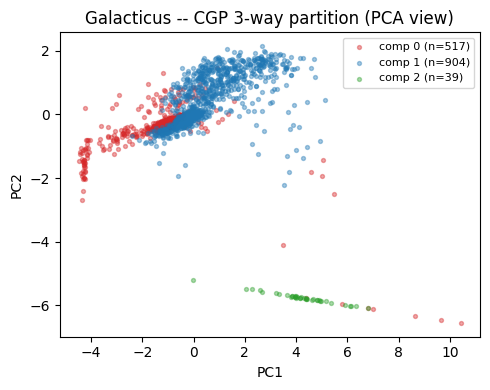

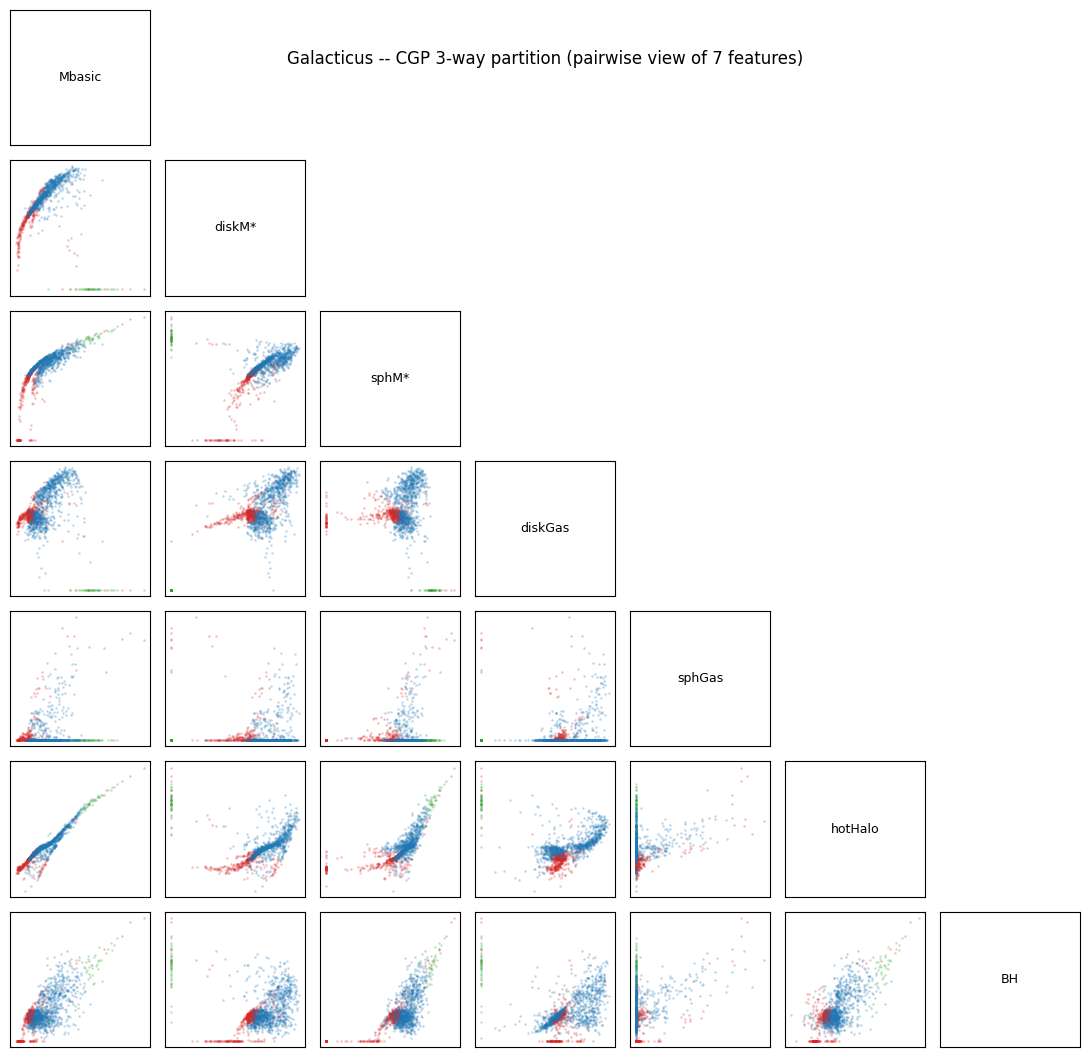

In [21]:
show_galacticus(3)   # K>2: exercises the multi-graph path